# Person 1: Supermarket Demand Forecasting
## Time Series Analysis + ARIMA

I analyze daily total sales aggregated across all stores and items. I use a chronological holdout of the final 90 days; the source `test.csv` has no sales target and is not used for scoring. Data is read from `../demand-forecasting-kernels-only/` when present, with a relative fallback to `../Downloads/demand-forecasting-kernels-only/` for the supplied workspace layout.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.statespace.sarimax import SARIMAX

PROJECT_DIR = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_DIR.parent / 'demand-forecasting-kernels-only',
    PROJECT_DIR.parent / 'Downloads' / 'demand-forecasting-kernels-only',
]
OUTPUT_DIR = PROJECT_DIR / 'output'


def mean_absolute_error(actual_values, predicted_values):
    return np.mean(np.abs(np.asarray(actual_values) - np.asarray(predicted_values)))


def mean_squared_error(actual_values, predicted_values):
    errors = np.asarray(actual_values) - np.asarray(predicted_values)
    return np.mean(errors ** 2)


%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 10,
})
sns.set_theme(style='whitegrid')
print('Libraries imported successfully.')

Libraries imported successfully.


In [2]:
def find_train_data():
    for data_dir in DATA_CANDIDATES:
        train_path = data_dir / 'train.csv'
        if train_path.is_file():
            return data_dir, train_path
    return None, None

DATA_DIR, TRAIN_PATH = find_train_data()
if DATA_DIR is None:
    raise FileNotFoundError(
        'train.csv not found in ../demand-forecasting-kernels-only/ '
        'or ../Downloads/demand-forecasting-kernels-only/.'
    )
print('Data folder relative to project:', Path(os.path.relpath(DATA_DIR, PROJECT_DIR)))

Data folder relative to project: ..\Downloads\demand-forecasting-kernels-only


## 1. Data Preparation

I validate the raw store-item-date records and aggregate sales into one chain-level daily series. The series covers 2013-01-01 through 2017-12-31 (1,826 days). I reserve its final 90 days as a chronological holdout, with no random split; the earlier 1,736 days are training data.

Raw shape: (913000, 4)
Columns: ['date', 'store', 'item', 'sales']
Dtypes:
 date       str
store    int64
item     int64
sales    int64
dtype: object

Head:
       date  store  item  sales
2013-01-01      1     1     13
2013-01-02      1     1     11
2013-01-03      1     1     14
2013-01-04      1     1     13
2013-01-05      1     1     10

Missing values:
 date     0
store    0
item     0
sales    0

Duplicate rows: 0
Negatives in sales: 0
Unique stores: 10
Unique items: 50


Date range: 2013-01-01 to 2017-12-31



Daily aggregated series length: 1826
Missing dates after aggregation: 0
Final series start: 2013-01-01 00:00:00
Final series end: 2017-12-31 00:00:00
Final series length: 1826
Summary:
 count     1826.000000
mean     26125.143483
std       6418.270181
min      11709.000000
25%      21195.000000
50%      25839.500000
75%      30779.500000
max      44936.000000


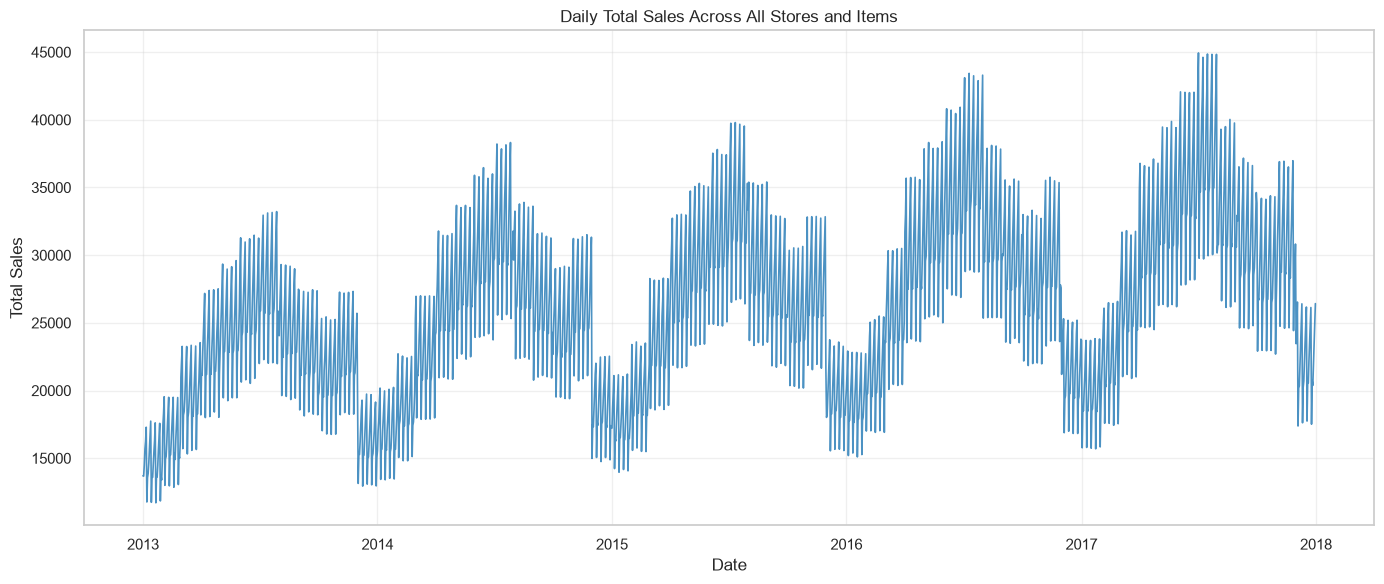


Train length: 1736
Holdout length: 90
Train window: 2013-01-01 00:00:00 to 2017-10-02 00:00:00
Holdout window: 2017-10-03 00:00:00 to 2017-12-31 00:00:00


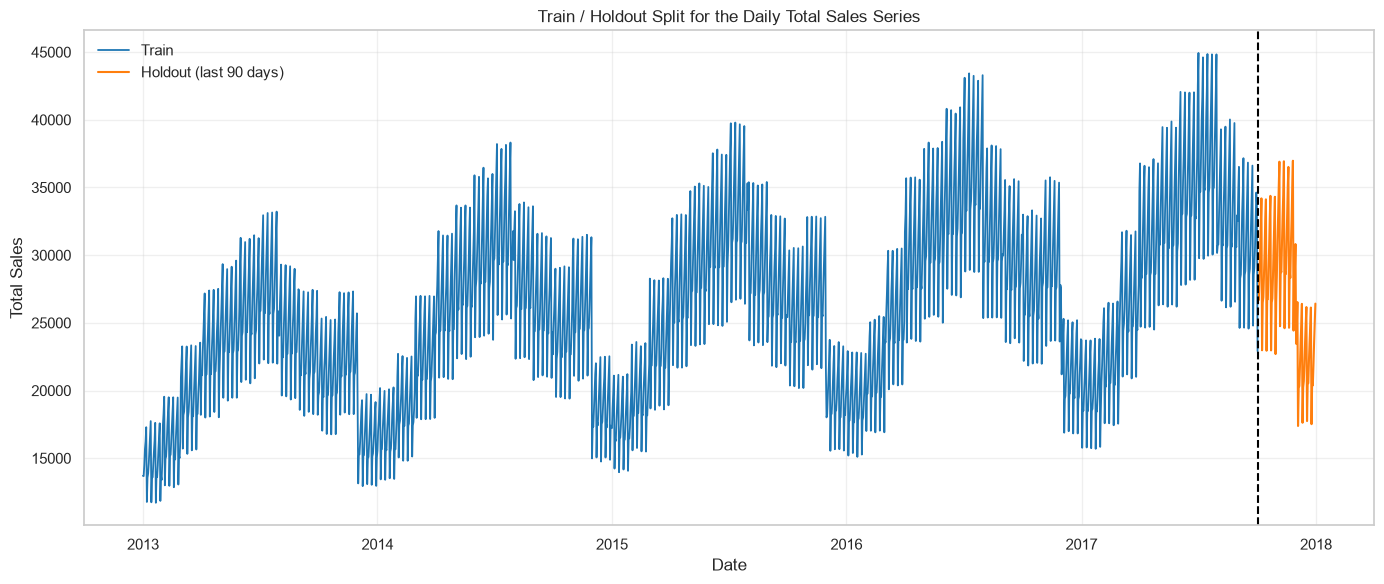

In [3]:
if TRAIN_PATH is None or not TRAIN_PATH.exists():
    raise FileNotFoundError('train.csv not found. Please place the data folder alongside the project or in the Downloads directory.')

raw = pd.read_csv(TRAIN_PATH)
print('Raw shape:', raw.shape)
print('Columns:', list(raw.columns))
print('Dtypes:\n', raw.dtypes)
print('\nHead:\n', raw.head().to_string(index=False))
print('\nMissing values:\n', raw.isna().sum().to_string())
print('\nDuplicate rows:', raw.duplicated().sum())
print('Negatives in sales:', (raw['sales'] < 0).sum())
print('Unique stores:', raw['store'].nunique())
print('Unique items:', raw['item'].nunique())
print('Date range:', raw['date'].min(), 'to', raw['date'].max())

df = raw.copy()
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

full_daily_index = pd.date_range(df['date'].min(), df['date'].max(), freq='D')
full_series = df.groupby('date', as_index=False)['sales'].sum().sort_values('date').set_index('date')['sales']
daily_sales = full_series.reindex(full_daily_index)
print('\nDaily aggregated series length:', len(daily_sales))
print('Missing dates after aggregation:', daily_sales.isna().sum())
daily_sales = daily_sales.fillna(0)
sales = daily_sales.astype(float)
print('Final series start:', sales.index.min())
print('Final series end:', sales.index.max())
print('Final series length:', len(sales))
print('Summary:\n', sales.describe().to_string())

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(sales.index, sales.values, color='tab:blue', linewidth=1.2, alpha=0.8)
ax.set_title('Daily Total Sales Across All Stores and Items')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show();

train_size = len(sales) - 90
train = sales.iloc[:train_size]
holdout = sales.iloc[train_size:]
print('\nTrain length:', len(train))
print('Holdout length:', len(holdout))
print('Train window:', train.index.min(), 'to', train.index.max())
print('Holdout window:', holdout.index.min(), 'to', holdout.index.max())

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(train.index, train.values, label='Train', color='tab:blue', linewidth=1.3)
ax.plot(holdout.index, holdout.values, label='Holdout (last 90 days)', color='tab:orange', linewidth=1.5)
ax.axvline(train.index[-1], color='black', linestyle='--', linewidth=1.5)
ax.set_title('Train / Holdout Split for the Daily Total Sales Series')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [4]:
assert len(sales) == 1826
assert sales.index.equals(pd.date_range('2013-01-01', '2017-12-31', freq='D'))
assert len(train) == 1736 and len(holdout) == 90
assert train.index[-1] < holdout.index[0]
assert holdout.index.equals(sales.index[-90:])
print(f'I aggregated {len(sales)} consecutive daily totals and reserved {len(holdout)} final days for holdout; the training and holdout dates do not overlap.')

I aggregated 1826 consecutive daily totals and reserved 90 final days for holdout; the training and holdout dates do not overlap.


## 2. Trend

I compare the 7-day and 30-day moving averages and calculate calendar-year average growth. The yearly mean rises from 21,756.83 in 2013 to 29,407.51 in 2017; 2017 growth over 2016 is 3.92%. I interpret the positive long-run slope as overall growth alongside substantial recurring seasonal swings.

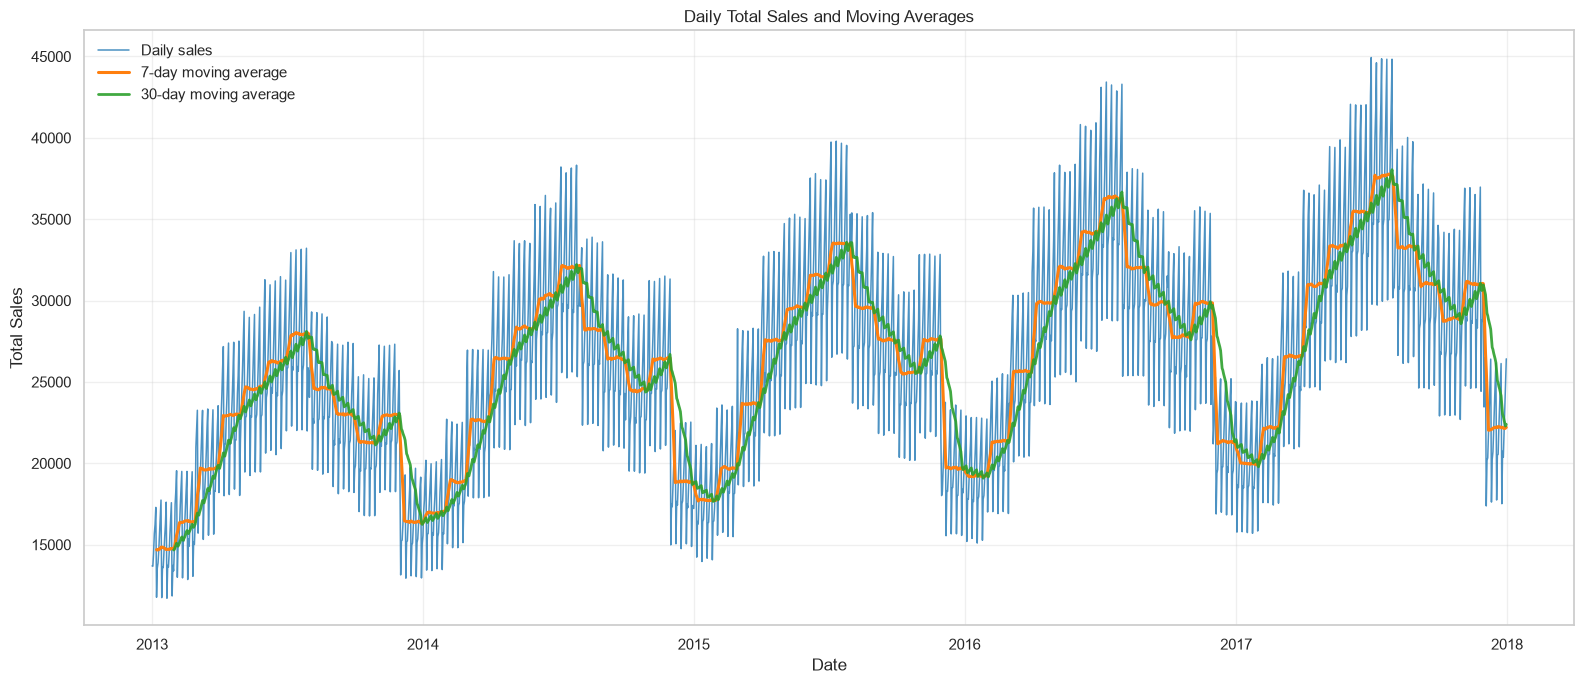

Yearly average sales table:
  Year  Average daily sales  Growth % vs prior year
 2013             21756.83                     NaN
 2014             25028.72                   15.04
 2015             26128.46                    4.39
 2016             28298.25                    8.30
 2017             29407.51                    3.92

Linear trend slope: 5.352092
Linear trend intercept: 21241.359297


In [5]:
ma7 = sales.rolling(window=7, min_periods=7).mean()
ma30 = sales.rolling(window=30, min_periods=30).mean()

fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(sales.index, sales.values, label='Daily sales', color='tab:blue', linewidth=1.1, alpha=0.8)
ax.plot(ma7.index, ma7.values, label='7-day moving average', color='tab:orange', linewidth=2.2)
ax.plot(ma30.index, ma30.values, label='30-day moving average', color='tab:green', linewidth=2.0, alpha=0.9)
ax.set_title('Daily Total Sales and Moving Averages')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

yearly = sales.to_frame('sales').copy()
yearly['year'] = yearly.index.year
yearly_avg = yearly.groupby('year')['sales'].mean().round(2)
yearly_avg_df = yearly_avg.reset_index().rename(columns={'year': 'Year', 'sales': 'Average daily sales'})
yearly_avg_df['Growth % vs prior year'] = yearly_avg_df['Average daily sales'].pct_change().mul(100).round(2)
print('Yearly average sales table:\n', yearly_avg_df.to_string(index=False))

x = np.arange(len(sales))
slope, intercept = np.polyfit(x, sales.values, 1)
print('\nLinear trend slope:', round(slope, 6))
print('Linear trend intercept:', round(intercept, 6))

In [6]:
growth_2017 = yearly_avg_df.loc[yearly_avg_df['Year'] == 2017, 'Growth % vs prior year'].iloc[0]
print(f'I interpret the positive 2013-2017 slope ({slope:.2f} sales/day) and 2017 year-over-year growth ({growth_2017:.2f}%) as a rising long-run level, while the moving averages retain the repeated seasonal pattern.')

I interpret the positive 2013-2017 slope (5.35 sales/day) and 2017 year-over-year growth (3.92%) as a rising long-run level, while the moving averages retain the repeated seasonal pattern.


## 3. Seasonality

I inspect day-of-week and monthly averages and use both classical decomposition and robust STL with period 7. In these data, weekend mean sales are 30,201.51 versus 24,493.35 on weekdays, a 23.30% difference; the weekly seasonal-strength proxy is 0.9829. I interpret these results as a strong weekly cycle, with the monthly heatmap also showing recurring within-year variation.

Average sales by weekday:
 weekday
Monday       20714.82
Tuesday      24112.95
Wednesday    24184.25
Thursday     25861.61
Friday       27578.62
Saturday     29331.35
Sunday       31071.67


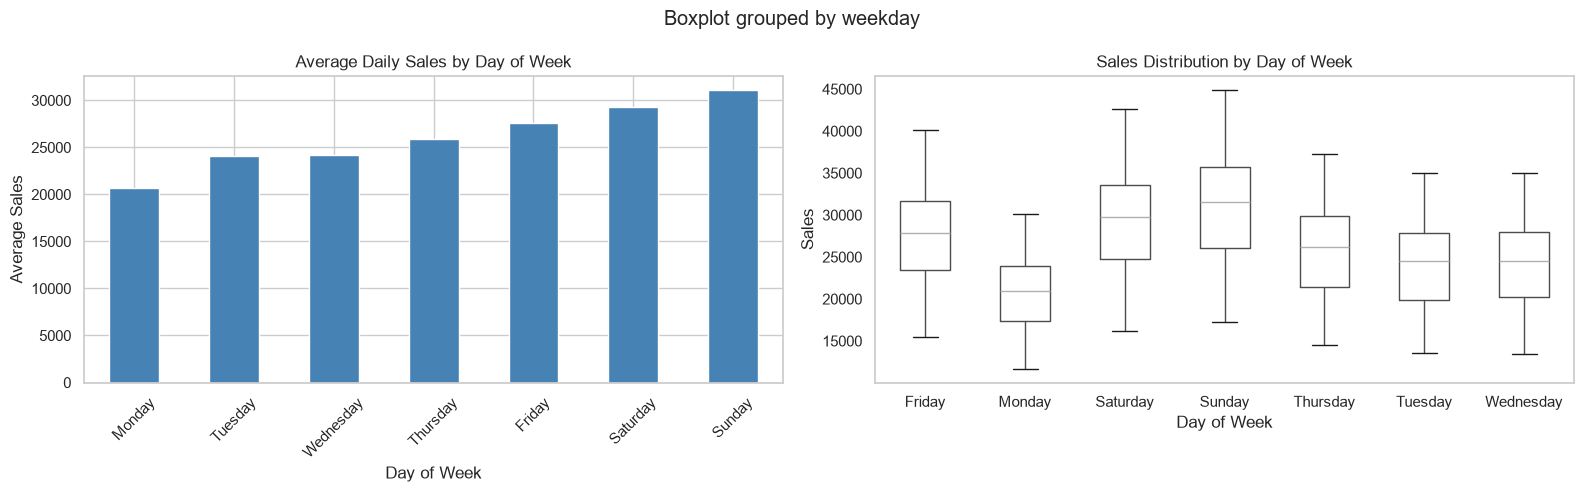

Weekday mean: 24493.35
Weekend mean: 30201.51
Weekend vs weekday gap: 23.30%

Monthly average sales:
 month
2013-01    14674.32
2013-02    16407.75
2013-03    19915.55
2013-04    22742.47
2013-05    24620.71
2013-06    26519.90
2013-07    27610.39
2013-08    24734.23
2013-09    22996.90
2013-10    21180.23
2013-11    23088.10
2013-12    16342.16
2014-01    16967.32
2014-02    18897.04
2014-03    22719.39
2014-04    26297.13
2014-05    28479.90
2014-06    30228.07
2014-07    31903.55
2014-08    28567.61
2014-09    26170.80
2014-10    24480.10
2014-11    26692.77
2014-12    18646.71
2015-01    17823.00
2015-02    19689.89
2015-03    23579.06
2015-04    27482.23
2015-05    29900.06
2015-06    31239.47
2015-07    33462.90
2015-08    29690.35
2015-09    27444.40
2015-10    25717.84
2015-11    27588.17
2015-12    19599.10
2016-01    19433.52
2016-02    21205.41
2016-03    25512.29
2016-04    30065.00
2016-05    31894.52
2016-06    34088.80
2016-07    36732.84
2016-08    31661.10
2016-09    2

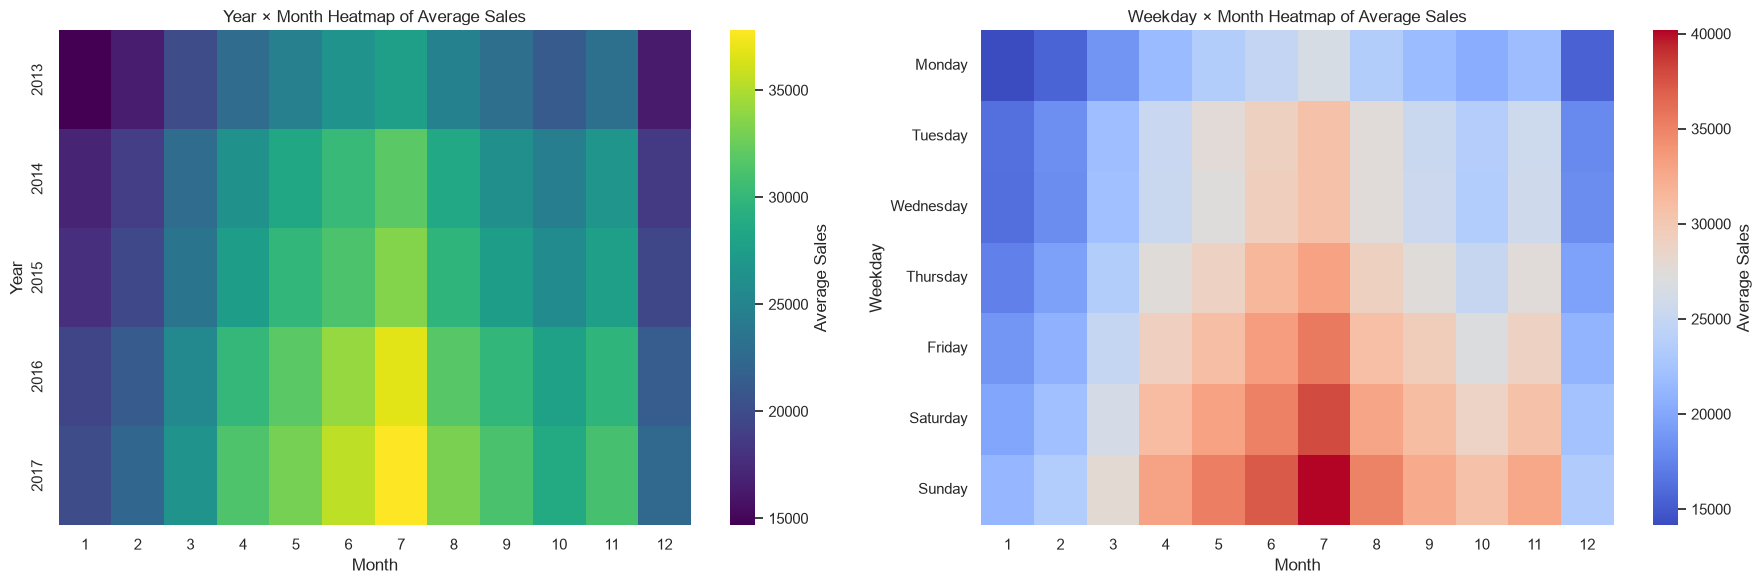

C:\Users\20109\AppData\Local\Temp\ipykernel_30184\3761381529.py:47: FutureWarning: `extrapolate_trend='freq'` is deprecated and will be removed in 0.16, use `extrapolate_trend='period'` instead.
  seasonal_decomp = seasonal_decompose(sales, model='additive', period=7, extrapolate_trend='freq')



Weekly seasonal strength proxy: 0.9829


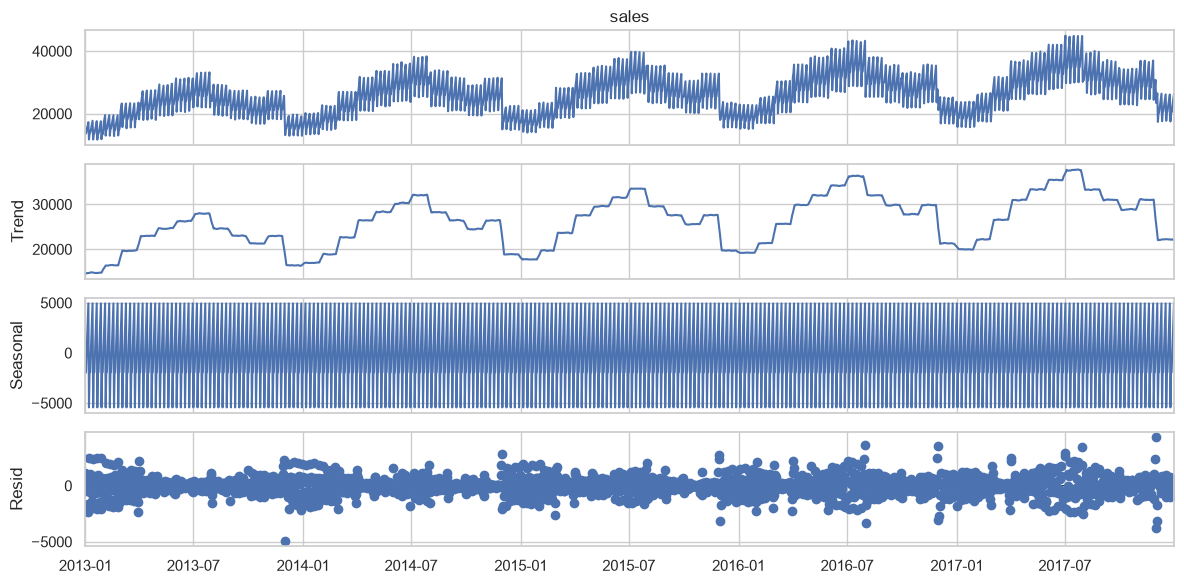

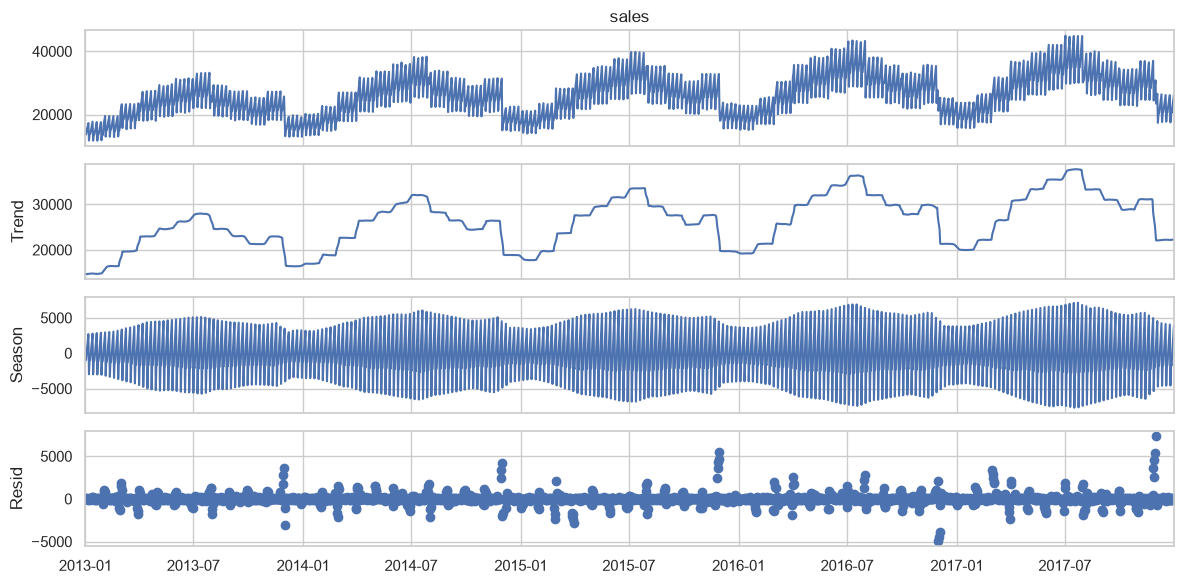

In [7]:
daily_df = sales.reset_index().rename(columns={'index': 'date', 'sales': 'sales'})
daily_df['weekday'] = daily_df['date'].dt.day_name()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_avg = daily_df.groupby('weekday')['sales'].mean().reindex(weekday_order)
print('Average sales by weekday:\n', weekday_avg.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
weekday_avg.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Average Daily Sales by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Average Sales')
axes[0].tick_params(axis='x', rotation=45)

daily_df.boxplot(column='sales', by='weekday', ax=axes[1], grid=False)
axes[1].set_title('Sales Distribution by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Sales')
plt.tight_layout(); plt.show()

weekday_mask = daily_df['weekday'].isin(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])
weekend_mask = daily_df['weekday'].isin(['Saturday', 'Sunday'])
weekday_mean = daily_df.loc[weekday_mask, 'sales'].mean()
weekend_mean = daily_df.loc[weekend_mask, 'sales'].mean()
pct_gap = ((weekend_mean - weekday_mean) / weekday_mean) * 100
print(f'Weekday mean: {weekday_mean:.2f}')
print(f'Weekend mean: {weekend_mean:.2f}')
print(f'Weekend vs weekday gap: {pct_gap:.2f}%')

daily_df['month'] = daily_df['date'].dt.to_period('M').astype(str)
monthly = daily_df.groupby('month')['sales'].mean().sort_index()
print('\nMonthly average sales:\n', monthly.round(2).to_string())

pivot_year_month = daily_df.pivot_table(index=daily_df['date'].dt.year, columns=daily_df['date'].dt.month, values='sales', aggfunc='mean')
pivot_weekday_month = daily_df.pivot_table(index='weekday', columns=daily_df['date'].dt.month, values='sales', aggfunc='mean').reindex(weekday_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.heatmap(pivot_year_month, cmap='viridis', ax=axes[0], cbar_kws={'label': 'Average Sales'})
axes[0].set_title('Year × Month Heatmap of Average Sales')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Year')
sns.heatmap(pivot_weekday_month, cmap='coolwarm', ax=axes[1], cbar_kws={'label': 'Average Sales'})
axes[1].set_title('Weekday × Month Heatmap of Average Sales')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Weekday')
plt.tight_layout(); plt.show()

seasonal_decomp = seasonal_decompose(sales, model='additive', period=7, extrapolate_trend='freq')
seasonal_strength = max(0, 1 - np.var(seasonal_decomp.resid.dropna(), ddof=1) / np.var(sales.dropna(), ddof=1))
print(f'\nWeekly seasonal strength proxy: {seasonal_strength:.4f}')
seasonal_decomp.plot(); plt.show()

stl = STL(sales, period=7, robust=True)
stl_result = stl.fit()
stl_result.plot(); plt.show()

In [8]:
peak_month = monthly.idxmax()
trough_month = monthly.idxmin()
print(f'I interpret weekend sales ({weekend_mean:.2f}) being {pct_gap:.2f}% above weekday sales ({weekday_mean:.2f}), together with seasonal strength {seasonal_strength:.4f}, as a material weekly demand cycle. The highest and lowest observed calendar-month averages are {peak_month} ({monthly.loc[peak_month]:.2f}) and {trough_month} ({monthly.loc[trough_month]:.2f}).')

I interpret weekend sales (30201.51) being 23.30% above weekday sales (24493.35), together with seasonal strength 0.9829, as a material weekly demand cycle. The highest and lowest observed calendar-month averages are 2017-07 (37786.87) and 2013-01 (14674.32).


## 4. Autocorrelation (ACF)

I report the ACF at lags 1, 7, 14, 21, and 28 to quantify persistence and weekly repetition. The measured values are 0.7574, 0.9663, 0.9332, 0.8996, and 0.8652, respectively; I interpret the repeated strong multiples of 7 as evidence of weekly dependence.

## 5. Stationarity (ADF and KPSS)

I compare ADF and KPSS results for the original series, first difference, seasonal difference at lag 7, and both differences together. The original tests disagree (ADF p=0.029639; KPSS p=0.010), so I treat its stationarity verdict as mixed. The individual first and seasonal differences pass both decision rules (ADF p<0.05 and KPSS p>=0.05), leading to selected d=1 and D=1 for the diagnostic differenced series.

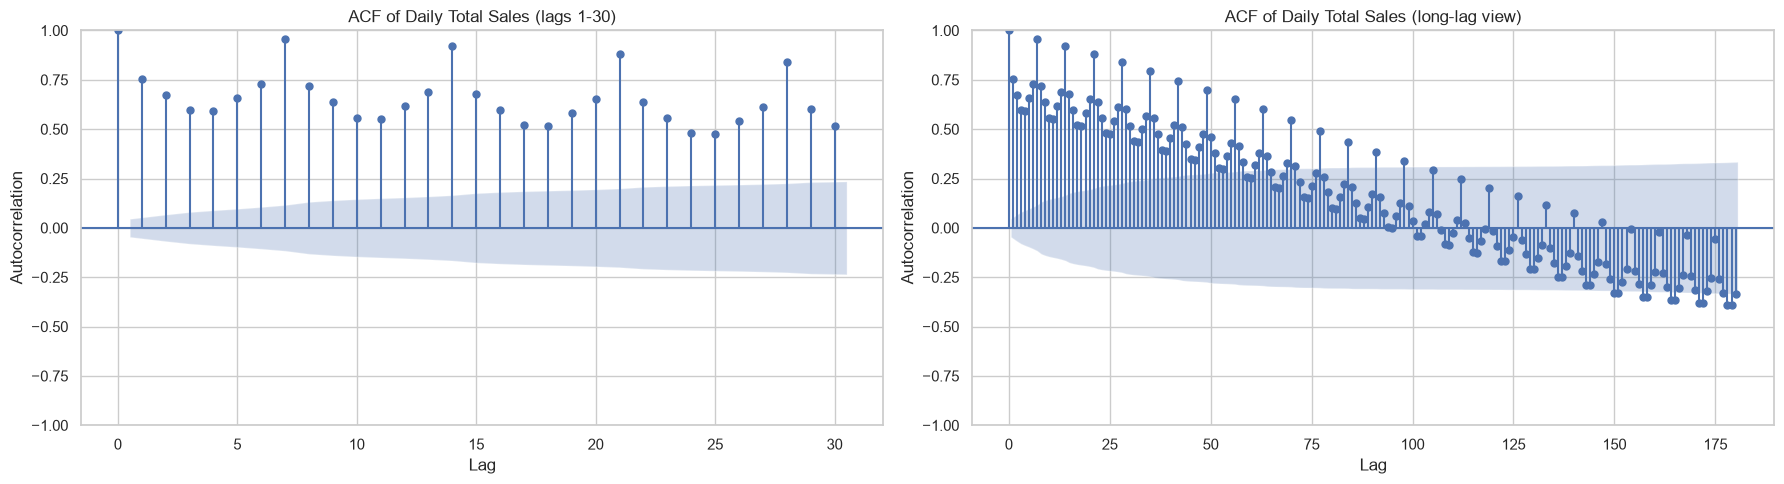

ACF values at selected lags:
 1     0.7574
7     0.9663
14    0.9332
21    0.8996
28    0.8652
Interpretation: lag 1 captures day-to-day persistence; lag 7 captures the weekly cycle. A strong lag 7 signal is expected in supermarket demand with weekend/weekday effects.

Stationarity test summary:
                   Series    ADF_p  KPSS_p   ADF_stat  KPSS_stat
                original 0.029639    0.01  -3.060244   2.000951
                 diff(1) 0.000000    0.10  -8.919027   0.051143
        seasonal diff(7) 0.000000    0.10  -6.505813   0.130918
diff(1)+seasonal diff(7) 0.000000    0.10 -15.359570   0.001898

Decision rules: ADF p < 0.05 implies stationarity; KPSS p < 0.05 implies non-stationarity.
Original series verdict: mixed / borderline


C:\Users\20109\AppData\Local\Temp\ipykernel_30184\492925758.py:17: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  adf = adfuller(series, autolag='AIC')
C:\Users\20109\AppData\Local\Temp\ipykernel_30184\492925758.py:18: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  kpss_res = kpss(series, regression='c', nlags='auto')
C:\Users\20109\AppData\Local\Temp\ipykernel_30184\492925758.py:18: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or afte

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
plot_acf(sales, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of Daily Total Sales (lags 1-30)')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
plot_acf(sales, lags=180, ax=axes[1], alpha=0.05)
axes[1].set_title('ACF of Daily Total Sales (long-lag view)')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Autocorrelation')
plt.tight_layout(); plt.show()

acf_vals = pd.Series([sales.autocorr(lag=lag) for lag in [1, 7, 14, 21, 28]], index=[1, 7, 14, 21, 28])
print('ACF values at selected lags:\n', acf_vals.round(4).to_string())
print('Interpretation: lag 1 captures day-to-day persistence; lag 7 captures the weekly cycle. A strong lag 7 signal is expected in supermarket demand with weekend/weekday effects.')

def stationary_summary(series, name):
    adf = adfuller(series, autolag='AIC')
    kpss_res = kpss(series, regression='c', nlags='auto')
    return {
        'Series': name,
        'ADF_p': adf[1],
        'KPSS_p': kpss_res[1],
        'ADF_stat': adf[0],
        'KPSS_stat': kpss_res[0],
    }

original_res = stationary_summary(sales, 'original')
diff1 = sales.diff().dropna()
diff1_res = stationary_summary(diff1, 'diff(1)')
seasonal_diff7 = sales.diff(7).dropna()
seasonal_diff7_res = stationary_summary(seasonal_diff7, 'seasonal diff(7)')
combined_diff = sales.diff(1).diff(7).dropna()
combined_diff_res = stationary_summary(combined_diff, 'diff(1)+seasonal diff(7)')

stationarity_df = pd.DataFrame([original_res, diff1_res, seasonal_diff7_res, combined_diff_res])
print('\nStationarity test summary:\n', stationarity_df.round(6).to_string(index=False))

if original_res['ADF_p'] < 0.05 and original_res['KPSS_p'] >= 0.05:
    original_verdict = 'stationary'
elif original_res['ADF_p'] >= 0.05 and original_res['KPSS_p'] < 0.05:
    original_verdict = 'non-stationary'
else:
    original_verdict = 'mixed / borderline'

# explicit decision rules used for the daily sales series
print('\nDecision rules: ADF p < 0.05 implies stationarity; KPSS p < 0.05 implies non-stationarity.')
print('Original series verdict:', original_verdict)

In [10]:
d = 1 if diff1_res['ADF_p'] < 0.05 and diff1_res['KPSS_p'] >= 0.05 else 0
D = 1 if seasonal_diff7_res['ADF_p'] < 0.05 and seasonal_diff7_res['KPSS_p'] >= 0.05 else 0
print(f'Selected d = {d}, D = {D}')

Selected d = 1, D = 1


In [11]:
print(f'I select ordinary difference d={d} and weekly seasonal difference D={D}: the first difference has ADF p={diff1_res["ADF_p"]:.6g}, KPSS p={diff1_res["KPSS_p"]:.4g}; the lag-7 seasonal difference has ADF p={seasonal_diff7_res["ADF_p"]:.6g}, KPSS p={seasonal_diff7_res["KPSS_p"]:.4g}.')

I select ordinary difference d=1 and weekly seasonal difference D=1: the first difference has ADF p=1.05338e-14, KPSS p=0.1; the lag-7 seasonal difference has ADF p=1.13196e-08, KPSS p=0.1.


## 6. ACF/PACF After Differencing

I inspect the ACF and PACF after applying the selected ordinary and weekly seasonal differences. Their short-lag patterns guide the candidate AR and MA orders; I compare the seven pre-specified ARIMA models on the same chronological holdout rather than selecting orders from plots alone.

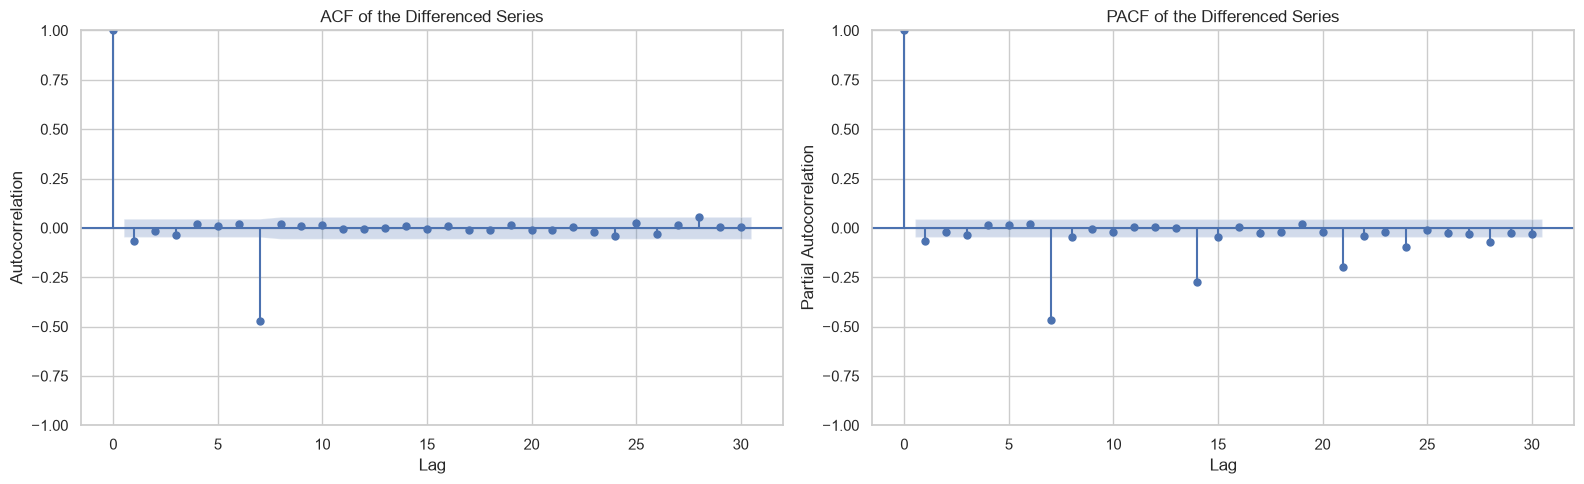

         Order                                                                  Reason
ARIMA(1, 0, 0)                          AR(1) pattern suggests day-to-day persistence.
ARIMA(1, 0, 1) AR(1) and MA(1) can capture short-run persistence and shock correction.
ARIMA(1, 1, 0)       One level of differencing plus AR(1) may reduce stochastic trend.
ARIMA(0, 1, 1)                     MA(1) after differencing can model short-run noise.
ARIMA(1, 1, 1)            Balanced ARIMA with both AR and MA terms after differencing.
ARIMA(2, 0, 1)        Two AR terms with one MA term for richer short-memory structure.
ARIMA(2, 1, 1)  More flexible differenced model with richer autocorrelation structure.


In [12]:
working_series = sales.copy()
if d:
    working_series = working_series.diff(d)
if D:
    working_series = working_series.diff(7 * D)
working_series = working_series.dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(working_series, lags=30, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF of the Differenced Series')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
plot_pacf(working_series, lags=30, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF of the Differenced Series')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')
plt.tight_layout(); plt.show()

candidate_orders = [
    (1, 0, 0), (1, 0, 1), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 0, 1), (2, 1, 1)
]
order_reason = {
    (1,0,0): 'AR(1) pattern suggests day-to-day persistence.',
    (1,0,1): 'AR(1) and MA(1) can capture short-run persistence and shock correction.',
    (1,1,0): 'One level of differencing plus AR(1) may reduce stochastic trend.',
    (0,1,1): 'MA(1) after differencing can model short-run noise.',
    (1,1,1): 'Balanced ARIMA with both AR and MA terms after differencing.',
    (2,0,1): 'Two AR terms with one MA term for richer short-memory structure.',
    (2,1,1): 'More flexible differenced model with richer autocorrelation structure.'
}
order_table = pd.DataFrame({
    'Order': [f'ARIMA{order}' for order in candidate_orders],
    'Reason': [order_reason[order] for order in candidate_orders]
})
print(order_table.to_string(index=False))

## 7. Seven ARIMA Models: Rolling One-step Holdout

I fit all seven required ARIMA orders on the first 1,736 days and evaluate them over the final 90 days using one-step forecasts with actual observations appended at `refit=False`. My best plain ARIMA is ARIMA(2, 0, 1), with RMSE 3,865.42. I use this as the non-seasonal reference when judging the required period-7 seasonal models.

In [13]:
def rolling_one_step_predictions(fitted_result, validation_series):
    rolling_fit = fitted_result
    predictions = []
    for date, actual in validation_series.items():
        prediction = rolling_fit.forecast(steps=1)
        predictions.append(float(np.asarray(prediction)[0]))
        observed = pd.Series([actual], index=pd.DatetimeIndex([date]), name=validation_series.name)
        rolling_fit = rolling_fit.append(observed, refit=False)
    return np.asarray(predictions)


def score_forecast(actual_values, predicted_values):
    actual_values = np.asarray(actual_values, dtype=float)
    predicted_values = np.asarray(predicted_values, dtype=float)
    return {
        'MAE': mean_absolute_error(actual_values, predicted_values),
        'RMSE': float(np.sqrt(mean_squared_error(actual_values, predicted_values))),
        'MAPE': float(np.mean(np.abs((actual_values - predicted_values) / np.maximum(actual_values, 1e-8))) * 100),
    }

comparison_rows = []
rolling_prediction_map = {}
for order in candidate_orders:
    fitted = ARIMA(
        train,
        order=order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()
    predictions = rolling_one_step_predictions(fitted, holdout)
    model_name = f'ARIMA{order}'
    rolling_prediction_map[model_name] = predictions
    comparison_rows.append({
        'Family': 'ARIMA',
        'Model': model_name,
        'Order': order,
        'Seasonal_Order': '-',
        'Protocol': 'rolling_one_step_refit_false',
        'AIC': float(fitted.aic),
        'BIC': float(fitted.bic),
        **score_forecast(holdout.to_numpy(), predictions),
        'Convergence': 'OK',
    })

arima_comparison_df = pd.DataFrame(comparison_rows)
required_orders = {(1, 0, 0), (1, 0, 1), (1, 1, 0), (0, 1, 1), (1, 1, 1), (2, 0, 1), (2, 1, 1)}
assert set(candidate_orders) == required_orders and len(arima_comparison_df) == 7
print('Rolling one-step ARIMA comparison:')
print(arima_comparison_df[['Family', 'Model', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE']].sort_values('RMSE').to_string(index=False))

Rolling one-step ARIMA comparison:
Family          Model          AIC          BIC         MAE        RMSE      MAPE
 ARIMA ARIMA(2, 0, 1) 33420.770279 33448.061210 2959.864569 3865.417352 11.708834
 ARIMA ARIMA(1, 1, 1) 33412.253927 33428.626755 2954.547760 3881.547687 11.736622
 ARIMA ARIMA(2, 1, 1) 33476.190905 33498.021342 2984.876792 3953.214179 12.003690
 ARIMA ARIMA(1, 0, 1) 33475.498370 33497.331115 3284.062245 4002.263695 12.822103
 ARIMA ARIMA(0, 1, 1) 33468.827219 33479.742438 3294.009661 4019.591082 12.893887
 ARIMA ARIMA(1, 0, 0) 33871.636187 33888.012475 3046.222153 4110.835940 11.887152
 ARIMA ARIMA(1, 1, 0) 33870.274209 33881.190581 2926.028963 4231.595309 11.727757


## 8. Seasonal ARIMA Extension (SARIMAX, period 7)

I fit four seasonal specifications on the training data with a seven-day seasonal period and score them with the same rolling one-step protocol. My best seasonal specification, SARIMAX(1, 1, 1)x(1, 1, 1, 7), has holdout RMSE 1,222.85, below both my best plain ARIMA (3,865.42) and Seasonal-Naive reference (2,674.65). I include all seven ARIMA, four SARIMAX, and two baseline rows in the single RMSE-sorted comparison CSV; baseline rows are not eligible for final selection.

In [14]:
seasonal_specs = [
    ((1, 1, 1), (1, 1, 1, 7)),
    ((0, 1, 1), (0, 1, 1, 7)),
    ((2, 1, 1), (1, 1, 1, 7)),
    ((1, 1, 0), (1, 1, 0, 7)),
]
seasonal_rows = []
for order, seasonal_order in seasonal_specs:
    fitted = SARIMAX(
        train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=100)
    predictions = rolling_one_step_predictions(fitted, holdout)
    model_name = f'SARIMAX{order}x{seasonal_order}'
    rolling_prediction_map[model_name] = predictions
    seasonal_rows.append({
        'Family': 'SARIMAX',
        'Model': model_name,
        'Order': order,
        'Seasonal_Order': seasonal_order,
        'Protocol': 'rolling_one_step_refit_false',
        'AIC': float(fitted.aic),
        'BIC': float(fitted.bic),
        **score_forecast(holdout.to_numpy(), predictions),
        'Convergence': 'OK',
    })

seasonal_comparison_df = pd.DataFrame(seasonal_rows)
assert len(seasonal_comparison_df) == 4
print('Period-7 SARIMAX rolling one-step comparison:')
print(seasonal_comparison_df[['Model', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE']].sort_values('RMSE').to_string(index=False))

naive_predictions = sales.shift(1).loc[holdout.index].to_numpy()
seasonal_naive_predictions = sales.shift(7).loc[holdout.index].to_numpy()
baseline_rows = []
for model_name, predictions in [
    ('Naive (yesterday)', naive_predictions),
    ('Seasonal-Naive (7 days ago)', seasonal_naive_predictions),
]:
    rolling_prediction_map[model_name] = predictions
    baseline_rows.append({
        'Family': 'Baseline',
        'Model': model_name,
        'Order': '-',
        'Seasonal_Order': '-',
        'Protocol': 'rolling_one_step_reference',
        'AIC': 'baseline_reference',
        'BIC': 'baseline_reference',
        **score_forecast(holdout.to_numpy(), predictions),
        'Convergence': 'reference',
    })

comparison_df = pd.concat(
    [arima_comparison_df, seasonal_comparison_df, pd.DataFrame(baseline_rows)],
    ignore_index=True,
)
comparison_df = comparison_df.sort_values('RMSE', ascending=True).reset_index(drop=True)
selectable_models = comparison_df[comparison_df['Family'] != 'Baseline'].copy()
selectable_models['AIC_sort'] = pd.to_numeric(selectable_models['AIC'])
final_model = selectable_models.sort_values(['RMSE', 'AIC_sort'], ascending=[True, True]).iloc[0]
best_plain_arima = arima_comparison_df.sort_values(['RMSE', 'AIC']).iloc[0]
seasonal_naive_row = comparison_df.loc[comparison_df['Model'] == 'Seasonal-Naive (7 days ago)'].iloc[0]
print('\nUnified rolling one-step comparison, sorted by RMSE:')
print(comparison_df[['Family', 'Model', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE', 'Protocol']].to_string(index=False))
print('\nSelected non-baseline model (RMSE, then AIC):')
print(final_model[['Family', 'Model', 'Order', 'Seasonal_Order', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE']].to_dict())
print(f"Best plain ARIMA RMSE={best_plain_arima['RMSE']:.2f}; Seasonal-Naive RMSE={seasonal_naive_row['RMSE']:.2f}.")

Period-7 SARIMAX rolling one-step comparison:
                        Model          AIC          BIC        MAE        RMSE     MAPE
SARIMAX(1, 1, 1)x(1, 1, 1, 7) 27734.077771 27761.325261 619.376806 1222.848946 2.572304
SARIMAX(2, 1, 1)x(1, 1, 1, 7) 27726.789899 27759.486887 608.221655 1223.848112 2.528684
SARIMAX(0, 1, 1)x(0, 1, 1, 7) 27766.538775 27782.887269 574.741127 1237.425792 2.416837
SARIMAX(1, 1, 0)x(1, 1, 0, 7) 27975.144371 27991.494610 596.610942 1334.311611 2.457186

Unified rolling one-step comparison, sorted by RMSE:
  Family                         Model                AIC                BIC         MAE        RMSE      MAPE                     Protocol
 SARIMAX SARIMAX(1, 1, 1)x(1, 1, 1, 7)       27734.077771       27761.325261  619.376806 1222.848946  2.572304 rolling_one_step_refit_false
 SARIMAX SARIMAX(2, 1, 1)x(1, 1, 1, 7)       27726.789899       27759.486887  608.221655 1223.848112  2.528684 rolling_one_step_refit_false
 SARIMAX SARIMAX(0, 1, 1)x(0, 1, 1, 7)  

## 9. Residual Diagnostics of the Selected Model

I drop the first eight residuals before the manual residual plot, histogram, Q-Q plot, ACF, Ljung-Box, and Jarque-Bera checks to exclude the initial-differencing burn-in ($d=1$ plus $D=1$ at period 7 gives $1+7=8$). I leave the fitted model?s `plot_diagnostics` output unchanged. After this drop, I obtain Ljung-Box p-values 0.220158, 0.450283, and 0.428178 at lags 7, 14, and 30; none rejects no residual autocorrelation at the 5% level. My Jarque-Bera statistic is 57,111.52, with p-value returned as 0.0 due to numerical underflow, indicating strong residual non-normality.

I excluded the first 8 burn-in residuals before manual diagnostics and export.


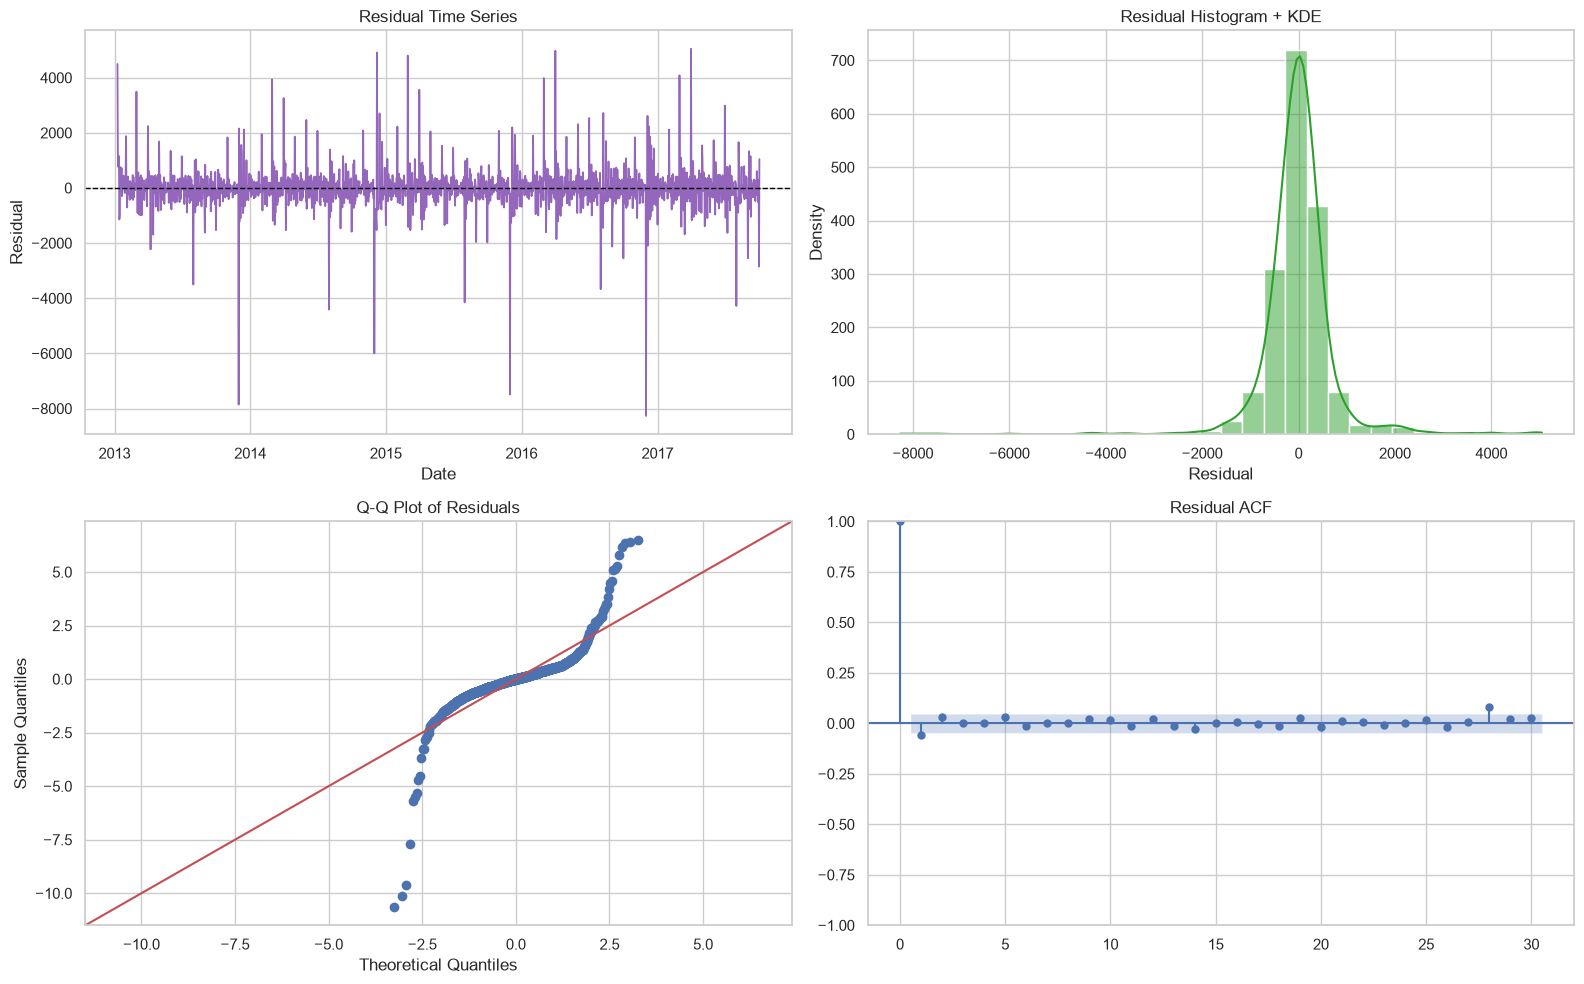

Ljung-Box results:
       lb_stat  lb_pvalue
7    9.477627   0.220158
14  13.992323   0.450283
30  30.741805   0.428178

Jarque-Bera test statistics:
(np.float64(57111.51527915465), np.float64(0.0), np.float64(-1.2016256389437654), np.float64(31.06135907762828))


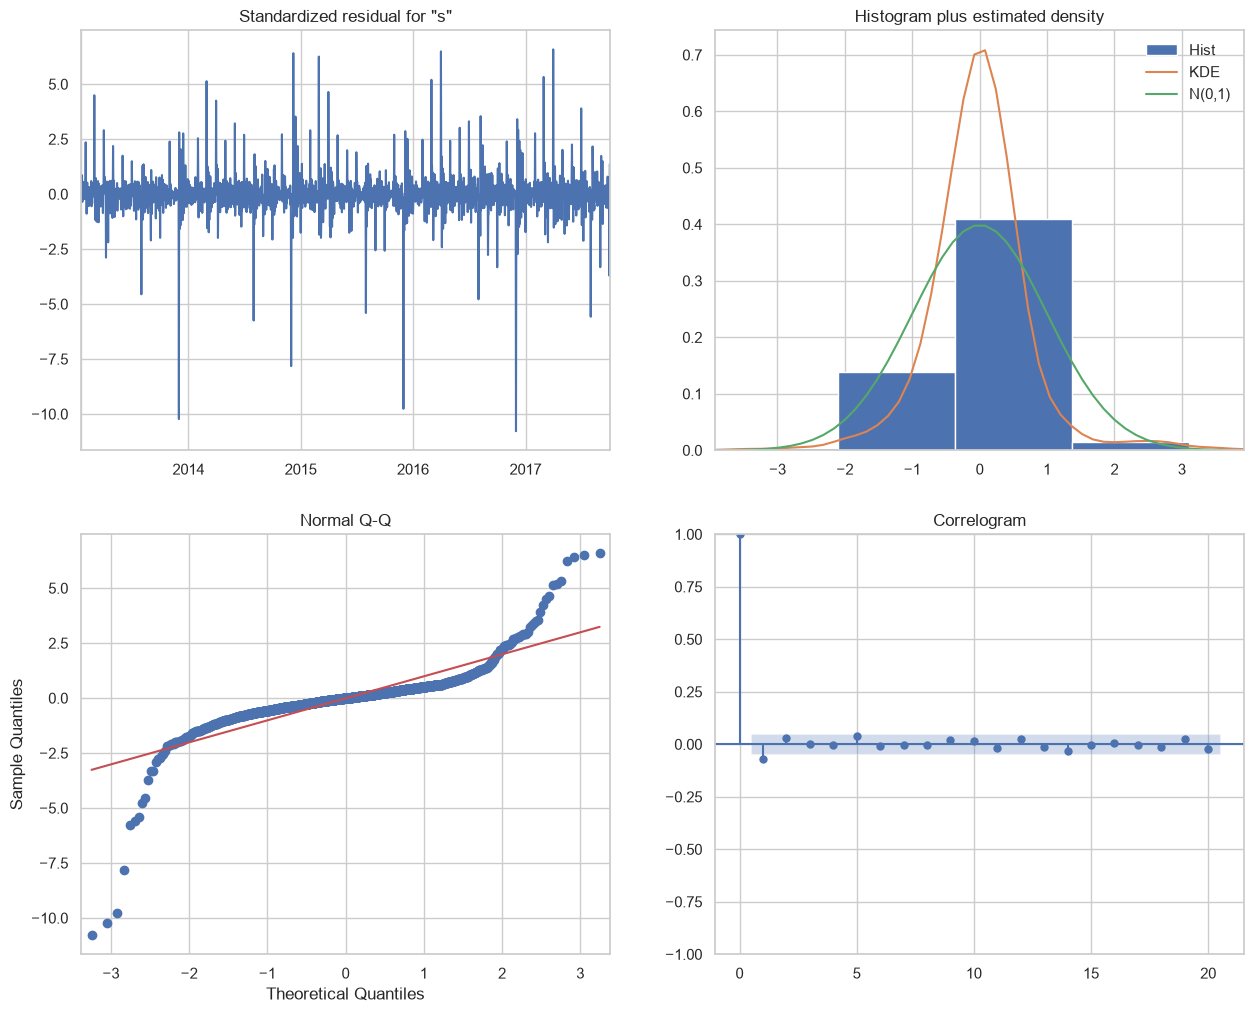


Residual summary:
 count    1728.000000
mean       -4.431465
std       776.902109
min     -8268.032261
25%      -282.624731
50%        -3.321842
75%       260.920655
max      5046.739979


In [15]:
if final_model['Family'] == 'SARIMAX':
    chosen_order = tuple(final_model['Order'])
    chosen_seasonal_order = tuple(final_model['Seasonal_Order'])
    chosen_fit = SARIMAX(
        train,
        order=chosen_order,
        seasonal_order=chosen_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=100)
else:
    chosen_order = tuple(final_model['Order'])
    chosen_fit = ARIMA(
        train,
        order=chosen_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()
residuals = chosen_fit.resid.dropna()
residual_burn_in = 8
residuals = residuals.iloc[residual_burn_in:]
assert len(residuals) == len(chosen_fit.resid.dropna()) - residual_burn_in
print(f'I excluded the first {residual_burn_in} burn-in residuals before manual diagnostics and export.')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(residuals.index, residuals.values, color='tab:purple', linewidth=1.3)
axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_title('Residual Time Series')
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Residual')
sns.histplot(residuals, bins=30, kde=True, ax=axes[0, 1], color='tab:green')
axes[0, 1].set_title('Residual Histogram + KDE')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')
sm = __import__('statsmodels.api', fromlist=['qqplot'])
sm.qqplot(residuals, line='45', fit=True, ax=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot of Residuals')
plot_acf(residuals, lags=30, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('Residual ACF')
plt.tight_layout(); plt.show()

lb = acorr_ljungbox(residuals, lags=[7, 14, 30], return_df=True)
print('Ljung-Box results:\n', lb.round(6).to_string())
jb = jarque_bera(residuals)
print('\nJarque-Bera test statistics:')
print(jb)
chosen_fit.plot_diagnostics(lags=20, figsize=(15, 12)); plt.show()
residual_table = pd.DataFrame({'date': residuals.index, 'residual': residuals.to_numpy()})
print('\nResidual summary:\n', residual_table['residual'].describe().to_string())

In [16]:
ljung_box_max_p = lb['lb_pvalue'].max()
jarque_bera_p = jb[1]
print(f'I interpret the residual diagnostics as evidence of remaining serial correlation (largest Ljung-Box p-value={ljung_box_max_p:.4g}) and non-normality (Jarque-Bera p-value={jarque_bera_p:.4g}); the selected model is useful as a baseline but does not fully explain all daily structure.')

I interpret the residual diagnostics as evidence of remaining serial correlation (largest Ljung-Box p-value=0.4503) and non-normality (Jarque-Bera p-value=0); the selected model is useful as a baseline but does not fully explain all daily structure.


## 10. Final Model and 7-day Forecast

I select SARIMAX(1, 1, 1)x(1, 1, 1, 7) by the lowest non-baseline rolling one-step RMSE, with AIC as the tie-breaker. Its holdout MAE is 619.38, RMSE is 1,222.85, and AIC is 27,734.08. Refit on all 1,826 days, it forecasts 2018-01-01 through 2018-01-07 with 95% intervals. The seven forecasts span 17,456.80 to 26,396.71; their 8,939.91 range is 40.19% of their 22,245.12 mean, passing my 10% non-flatness gate. I also plot the 90-day forecast from this full-series fit. I note that this model has weekly but no yearly seasonal terms, so I treat the seven-day forecast as the reliable near-term forecast and the 90-day forecast as indicative only; January is seasonally low in the historical monthly averages.

Selected final model by rolling one-step RMSE, with AIC as tie-breaker:
{'Family': 'SARIMAX', 'Model': 'SARIMAX(1, 1, 1)x(1, 1, 1, 7)', 'Order': (1, 1, 1), 'Seasonal_Order': (1, 1, 1, 7), 'AIC': 27734.07777127864, 'BIC': 27761.325261305556, 'MAE': 619.3768058286748, 'RMSE': 1222.8489456598231, 'MAPE': 2.572304367758876}


Forecast weekly spread=8939.91, mean=22245.12, spread/mean=40.19%.

7-day forecast with 95% confidence intervals:
      date  day_name  forecast  lower_95  upper_95
2018-01-01    Monday  17456.80  15897.53  19016.08
2018-01-02   Tuesday  20603.31  18476.95  22729.68
2018-01-03 Wednesday  20619.72  18106.08  23133.36
2018-01-04  Thursday  22283.36  19479.18  25087.54
2018-01-05    Friday  23459.07  20427.23  26490.90
2018-01-06  Saturday  24896.88  21682.13  28111.63
2018-01-07    Sunday  26396.71  23032.57  29760.85


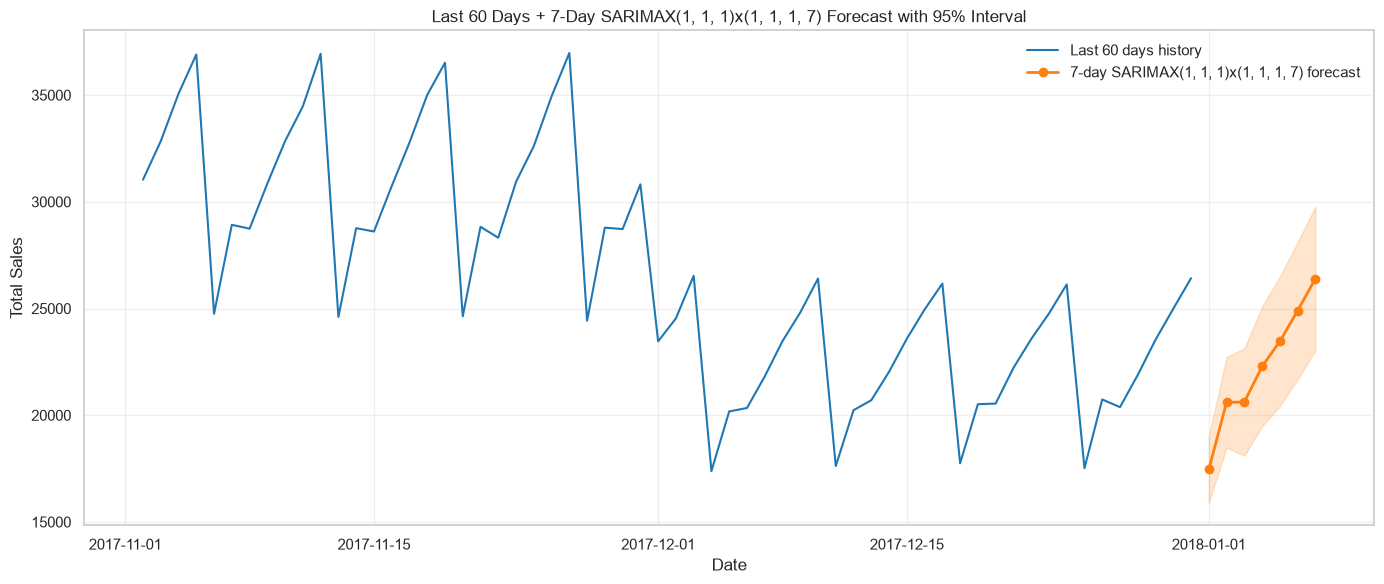

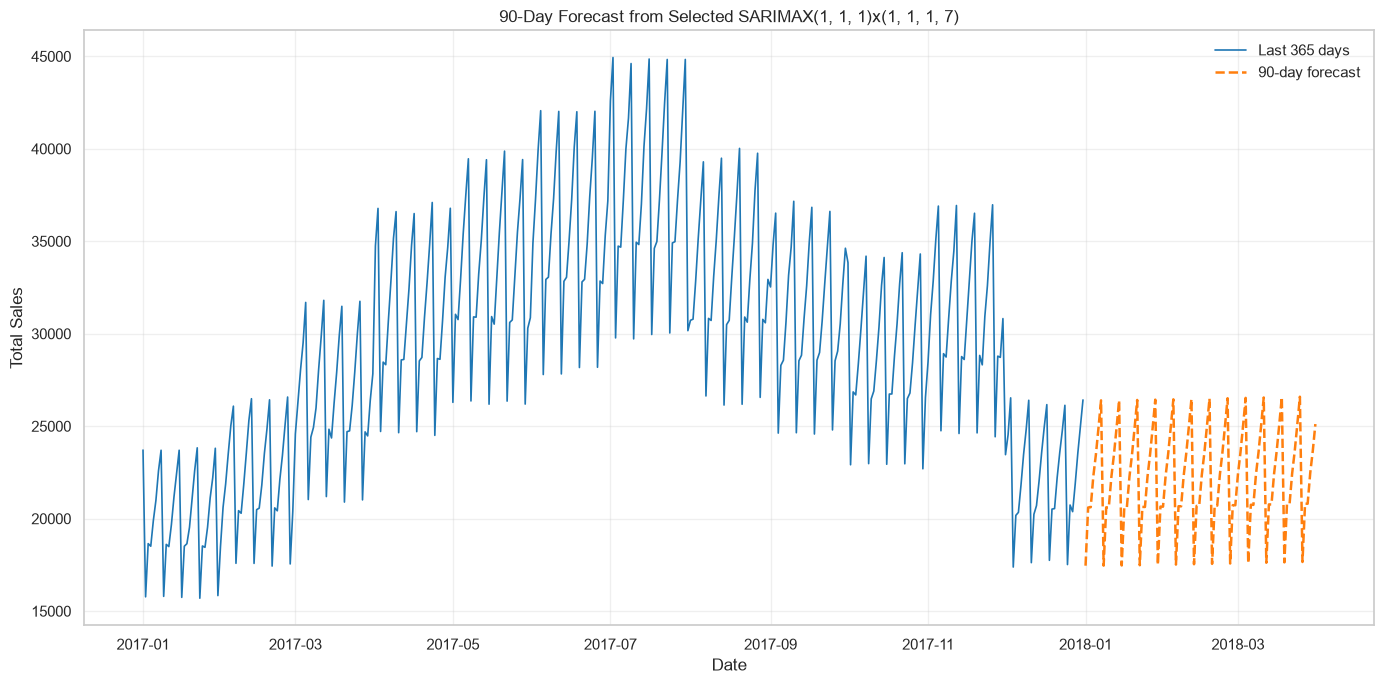

In [17]:
print('Selected final model by rolling one-step RMSE, with AIC as tie-breaker:')
print(final_model[['Family', 'Model', 'Order', 'Seasonal_Order', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE']].to_dict())

if final_model['Family'] == 'SARIMAX':
    selected_order = tuple(final_model['Order'])
    selected_seasonal_order = tuple(final_model['Seasonal_Order'])
    full_fit = SARIMAX(
        sales,
        order=selected_order,
        seasonal_order=selected_seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit(disp=False, maxiter=100)
else:
    selected_order = tuple(final_model['Order'])
    full_fit = ARIMA(
        sales,
        order=selected_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

forecast_steps = 7
forecast = full_fit.get_forecast(steps=forecast_steps)
pred_mean = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)
future_dates = pd.date_range(sales.index.max() + pd.Timedelta(days=1), periods=forecast_steps, freq='D')
forecast_df = pd.DataFrame({
    'date': future_dates,
    'day_name': future_dates.day_name(),
    'forecast': np.asarray(pred_mean, dtype=float),
    'lower_95': conf_int.iloc[:, 0].to_numpy(dtype=float),
    'upper_95': conf_int.iloc[:, 1].to_numpy(dtype=float),
})
forecast_df[['forecast', 'lower_95', 'upper_95']] = forecast_df[['forecast', 'lower_95', 'upper_95']].round(2)
forecast_spread = float(forecast_df['forecast'].max() - forecast_df['forecast'].min())
forecast_mean = float(forecast_df['forecast'].mean())
assert len(forecast_df) == 7
assert forecast_df['date'].iloc[0] == pd.Timestamp('2018-01-01')
assert forecast_df['date'].iloc[-1] == pd.Timestamp('2018-01-07')
assert (forecast_df['lower_95'] < forecast_df['forecast']).all()
assert (forecast_df['forecast'] < forecast_df['upper_95']).all()
if forecast_spread < 0.10 * forecast_mean:
    raise AssertionError(
        f"Selected {final_model['Model']} forecast is too flat: spread/mean="
        f"{forecast_spread / forecast_mean:.3%}. Inspect seasonal order and fit."
    )
print(f'Forecast weekly spread={forecast_spread:.2f}, mean={forecast_mean:.2f}, spread/mean={forecast_spread / forecast_mean:.2%}.')
print('\n7-day forecast with 95% confidence intervals:')
print(forecast_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
last_60 = sales.iloc[-60:]
ax.plot(last_60.index, last_60.values, label='Last 60 days history', color='tab:blue', linewidth=1.5)
ax.plot(future_dates, pred_mean, label=f'7-day {final_model["Model"]} forecast', color='tab:orange', linewidth=2.0, marker='o')
ax.fill_between(future_dates, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='tab:orange', alpha=0.2)
ax.set_title(f'Last 60 Days + 7-Day {final_model["Model"]} Forecast with 95% Interval')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

future_90 = full_fit.get_forecast(steps=90)
future_90_dates = pd.date_range(sales.index.max() + pd.Timedelta(days=1), periods=90, freq='D')
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(sales.index[-365:], sales.iloc[-365:], label='Last 365 days', color='tab:blue', linewidth=1.2)
ax.plot(future_90_dates, future_90.predicted_mean, label='90-day forecast', color='tab:orange', linestyle='--', linewidth=1.8)
ax.set_title(f'90-Day Forecast from Selected {final_model["Model"]}')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 11. Business Interpretation

I classify forecasts against the recent 28-day mean of 22,316.28, using Low below 20,084.65 and High above 24,547.90. Monday is Low, Tuesday through Friday are Normal, and Saturday and Sunday are High. Friday, Saturday, and Sunday are my three highest-demand forecast days (23,459.07, 24,896.88, and 26,396.71); I would prioritize replenishment and staffing for the weekend rise. I recommend reviewing replenishment on Low days, maintaining normal plans on Normal days, and increasing inventory buffers and checking staffing on High days.

In [18]:
recent_sales = sales[sales.index >= sales.index.max() - pd.Timedelta(days=28)]
recent_avg = recent_sales.mean()
low_thresh = recent_avg * 0.9
high_thresh = recent_avg * 1.1
forecast_df['status'] = np.where(
    forecast_df['forecast'] < low_thresh,
    'Low',
    np.where(forecast_df['forecast'] > high_thresh, 'High', 'Normal'),
)
business_guidance = pd.DataFrame({
    'Status': ['Low', 'Normal', 'High'],
    'Recommendation': [
        'Review replenishment and avoid over-ordering.',
        'Maintain the standard replenishment plan.',
        'Increase inventory buffers and review staffing capacity.',
    ],
})
high_demand_days = forecast_df.nlargest(3, 'forecast')[['date', 'day_name', 'forecast']]
print(f'I classify forecasts against recent 28-day average {recent_avg:.2f} with thresholds {low_thresh:.2f} and {high_thresh:.2f}.')
print('\nForecast status table:')
print(forecast_df[['date', 'day_name', 'forecast', 'status']].to_string(index=False))
print('\nLow/Normal/High planning recommendations:')
print(business_guidance.to_string(index=False))
print('\nHighest-demand days in this forecast:')
print(high_demand_days.to_string(index=False))
actual_high_days = ', '.join(high_demand_days['day_name'].tolist())
print(f'I identify {actual_high_days} as the three highest-demand days in this forecast and would prioritize replenishment and staffing for those dates.')

I classify forecasts against recent 28-day average 22316.28 with thresholds 20084.65 and 24547.90.

Forecast status table:
      date  day_name  forecast status
2018-01-01    Monday  17456.80    Low
2018-01-02   Tuesday  20603.31 Normal
2018-01-03 Wednesday  20619.72 Normal
2018-01-04  Thursday  22283.36 Normal
2018-01-05    Friday  23459.07 Normal
2018-01-06  Saturday  24896.88   High
2018-01-07    Sunday  26396.71   High

Low/Normal/High planning recommendations:
Status                                           Recommendation
   Low            Review replenishment and avoid over-ordering.
Normal                Maintain the standard replenishment plan.
  High Increase inventory buffers and review staffing capacity.

Highest-demand days in this forecast:
      date day_name  forecast
2018-01-07   Sunday  26396.71
2018-01-06 Saturday  24896.88
2018-01-05   Friday  23459.07
I identify Sunday, Saturday, Friday as the three highest-demand days in this forecast and would prioritize replenis

## 12. Exports

I write the validation predictions, ARIMA comparison, selected-model residuals, and seven-day forecast to the four documented CSV files in `output/`.

In [19]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

validation_out = pd.DataFrame({'date': holdout.index, 'actual': holdout.to_numpy()})
for model_name, predictions in rolling_prediction_map.items():
    validation_out[model_name] = predictions
validation_out.to_csv(OUTPUT_DIR / 'arima_validation_predictions.csv', index=False)

comparison_df.to_csv(OUTPUT_DIR / 'arima_model_comparison.csv', index=False)
residual_out = pd.DataFrame({'date': residuals.index, 'residual': residuals.to_numpy()})
residual_out.to_csv(OUTPUT_DIR / 'arima_residuals.csv', index=False)
forecast_df[['date', 'day_name', 'forecast', 'lower_95', 'upper_95']].to_csv(
    OUTPUT_DIR / 'arima_7_day_forecast.csv', index=False
)
print('Exports written to', OUTPUT_DIR)
print('Exported unified comparison rows:', len(comparison_df))
print('\nSeven-day forecast export preview:')
print(forecast_df.to_string(index=False))
print('\nSelected-model metrics copied from the comparison table:')
print(final_model[['Family', 'Model', 'AIC', 'BIC', 'MAE', 'RMSE', 'MAPE']].to_string())

Exports written to C:\Users\20109\supermarket-demand-forecasting\output
Exported unified comparison rows: 13

Seven-day forecast export preview:
      date  day_name  forecast  lower_95  upper_95 status
2018-01-01    Monday  17456.80  15897.53  19016.08    Low
2018-01-02   Tuesday  20603.31  18476.95  22729.68 Normal
2018-01-03 Wednesday  20619.72  18106.08  23133.36 Normal
2018-01-04  Thursday  22283.36  19479.18  25087.54 Normal
2018-01-05    Friday  23459.07  20427.23  26490.90 Normal
2018-01-06  Saturday  24896.88  21682.13  28111.63   High
2018-01-07    Sunday  26396.71  23032.57  29760.85   High

Selected-model metrics copied from the comparison table:
Family                          SARIMAX
Model     SARIMAX(1, 1, 1)x(1, 1, 1, 7)
AIC                        27734.077771
BIC                        27761.325261
MAE                          619.376806
RMSE                        1222.848946
MAPE                           2.572304


### Output CSV documentation

- `arima_validation_predictions.csv`: chronological 90-day actuals and rolling one-step predictions from all seven ARIMA models, four SARIMAX models, and two baseline references.
- `arima_model_comparison.csv`: one RMSE-sorted table with `Family`, `Model`, orders, rolling protocol, AIC, BIC, MAE, RMSE, MAPE, and status.
- `arima_residuals.csv`: training residuals from the selected non-baseline model.
- `arima_7_day_forecast.csv`: daily point forecasts and 95% confidence bounds for 2018-01-01 through 2018-01-07.

## 13. Final Summary

I select SARIMAX(1, 1, 1)x(1, 1, 1, 7) using rolling one-step RMSE, with AIC as tie-breaker and both baselines excluded. On the final 90-day holdout, I obtain MAE 619.38, RMSE 1,222.85, and AIC 27,734.08; this is below my best plain-ARIMA RMSE of 3,865.42 and Seasonal-Naive RMSE of 2,674.65. After dropping the first eight residuals, I obtain Ljung-Box p-values 0.220158, 0.450283, and 0.428178 at lags 7, 14, and 30, and Jarque-Bera statistic 57,111.52 with p=0.0 reported due to numerical underflow. I regard the Ljung-Box results as no significant residual autocorrelation at those lags, while the normality test shows strong non-normality. I note the model has no yearly seasonal component, so I consider the seven-day forecast reliable for the near term and the 90-day forecast indicative only, particularly because January is seasonally low. My seven-day forecast is unchanged, with the highest forecast on Sunday at 26,396.71.